# <div style="color:#fff;display:fill;border-radius:10px;background-color:#000080;text-align:center;letter-spacing:0.1px;overflow:hidden;padding:20px;color:white;overflow:hidden;margin:0;mfont-size:100%">Human vital signs </div>

# 📚 Import Libraries

In [87]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.utils.class_weight import compute_sample_weight

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import joblib


# 📚 Reading Dataset

In [88]:
data = pd.read_csv("Human_vital_signs_R.csv")
df=data.copy()
df

,Unnamed: 0,Time (s),HR (BPM),RESP (BPM),SpO2 (%),TEMP (*C),OUTPUT
0,0,0,94.0,21.0,97.0,36.2,Normal
1,1,1,94.0,25.0,97.0,36.2,Normal
2,2,2,101.0,25.0,93.0,38.0,Abnormal
3,3,3,55.0,11.0,100.0,35.0,Abnormal
4,4,4,93.0,26.0,95.0,37.0,Normal
...,...,...,...,...,...,...,...
25488,476,476,56.0,12.0,101.0,33.0,Abnormal
25489,477,477,94.0,25.0,98.0,36.4,Normal
25490,478,478,94.0,21.0,97.0,36.2,Normal
25491,479,479,93.0,27.0,95.0,37.0,Normal


In [89]:
df.head()

,Unnamed: 0,Time (s),HR (BPM),RESP (BPM),SpO2 (%),TEMP (*C),OUTPUT
0,0,0,94.0,21.0,97.0,36.2,Normal
1,1,1,94.0,25.0,97.0,36.2,Normal
2,2,2,101.0,25.0,93.0,38.0,Abnormal
3,3,3,55.0,11.0,100.0,35.0,Abnormal
4,4,4,93.0,26.0,95.0,37.0,Normal


In [90]:
df.tail()

,Unnamed: 0,Time (s),HR (BPM),RESP (BPM),SpO2 (%),TEMP (*C),OUTPUT
25488,476,476,56.0,12.0,101.0,33.0,Abnormal
25489,477,477,94.0,25.0,98.0,36.4,Normal
25490,478,478,94.0,21.0,97.0,36.2,Normal
25491,479,479,93.0,27.0,95.0,37.0,Normal
25492,480,480,102.0,25.0,92.0,37.0,Abnormal


## 🔍Initial Data Exploration

In [91]:
print(f'📊 Data Shape: {df.shape}')
print(f'📊 Number of rows: {df.shape[0]}')
print(f'📊 Number of columns: {df.shape[1]}')

📊 Data Shape: (25493, 7)
📊 Number of rows: 25493
📊 Number of columns: 7


In [92]:
df.describe()

,Unnamed: 0,Time (s),HR (BPM),RESP (BPM),SpO2 (%),TEMP (*C)
count,25493.000000,25493.000000,25488.000000,25346.000000,25366.000000,25493.000000
mean,240.000000,239.981132,89.127943,17.640496,96.716471,37.590123
std,138.855163,138.855230,13.220448,3.589381,3.323381,5.211265
min,0.000000,-1.000000,44.000000,0.000000,83.000000,21.000000
25%,120.000000,120.000000,81.000000,16.000000,95.000000,34.000000
50%,240.000000,240.000000,89.000000,18.000000,97.000000,38.000000
75%,360.000000,360.000000,95.000000,20.000000,99.000000,41.000000
max,480.000000,480.000000,139.000000,34.000000,111.000000,49.000000


In [93]:
print('📝 Column Names:')
print(df.columns.tolist())

📝 Column Names:
['Unnamed: 0', 'Time (s)', ' HR (BPM)', ' RESP (BPM)', ' SpO2 (%)', 'TEMP (*C)', 'OUTPUT']


## 🎯Time Feature
## The Time (s) column represents the time of each measurement in seconds.
## We will keep it for now and analyze its relationship with the target before deciding whether to use it in the model.

In [94]:
df = df.drop(columns=["Unnamed: 0"])

## 🎯Removing the Unnamed Column
## The Unnamed: 0 column is an unnecessary index column, so it will be removed before further analysis.

In [95]:
print('📝 Column Names:')
print(df.columns.tolist())

📝 Column Names:
['Time (s)', ' HR (BPM)', ' RESP (BPM)', ' SpO2 (%)', 'TEMP (*C)', 'OUTPUT']


In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25493 entries, 0 to 25492
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Time (s)     25493 non-null  int64  
 1    HR (BPM)    25488 non-null  float64
 2    RESP (BPM)  25346 non-null  float64
 3    SpO2 (%)    25366 non-null  float64
 4   TEMP (*C)    25493 non-null  float64
 5   OUTPUT       25493 non-null  object 
dtypes: float64(4), int64(1), object(1)
memory usage: 1.2+ MB


In [97]:
df.nunique()

Time (s)       482
 HR (BPM)       87
 RESP (BPM)     34
 SpO2 (%)       19
TEMP (*C)       31
OUTPUT           2
dtype: int64

In [98]:
print('📊 Descriptive Statistics (Numerical):')
df.describe()

📊 Descriptive Statistics (Numerical):


,Time (s),HR (BPM),RESP (BPM),SpO2 (%),TEMP (*C)
count,25493.000000,25488.000000,25346.000000,25366.000000,25493.000000
mean,239.981132,89.127943,17.640496,96.716471,37.590123
std,138.855230,13.220448,3.589381,3.323381,5.211265
min,-1.000000,44.000000,0.000000,83.000000,21.000000
25%,120.000000,81.000000,16.000000,95.000000,34.000000
50%,240.000000,89.000000,18.000000,97.000000,38.000000
75%,360.000000,95.000000,20.000000,99.000000,41.000000
max,480.000000,139.000000,34.000000,111.000000,49.000000


In [99]:
print('📊 Descriptive Statistics (Categorical):')
df.describe(include='object')

📊 Descriptive Statistics (Categorical):


,OUTPUT
count,25493
unique,2
top,Abnormal
freq,19702


In [100]:
print('🔢 Data Types:')
print(df.dtypes)

🔢 Data Types:
Time (s)         int64
 HR (BPM)      float64
 RESP (BPM)    float64
 SpO2 (%)      float64
TEMP (*C)      float64
OUTPUT          object
dtype: object


In [101]:
print('❌ Missing Values in Each Column:')
null_counts = df.isnull().sum()
print(null_counts)

❌ Missing Values in Each Column:
Time (s)         0
 HR (BPM)        5
 RESP (BPM)    147
 SpO2 (%)      127
TEMP (*C)        0
OUTPUT           0
dtype: int64


In [102]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

missing = missing.sort_values(
    by="Missing Count",
    ascending=False
)

display(missing)

,Missing Count,Missing Percentage
RESP (BPM),147,0.576629
SpO2 (%),127,0.498176
HR (BPM),5,0.019613
Time (s),0,0.000000
TEMP (*C),0,0.000000
OUTPUT,0,0.000000


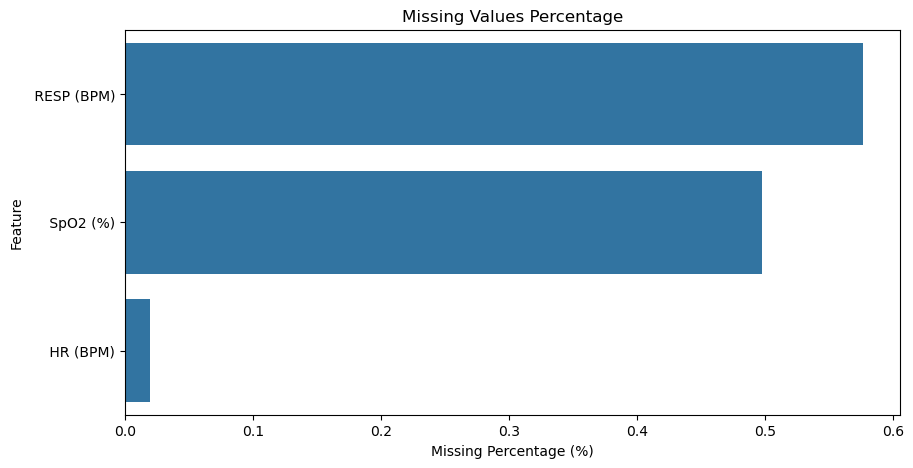

In [103]:
missing_plot = missing[missing["Missing Count"] > 0]

if len(missing_plot) > 0:
    plt.figure(figsize=(10, 5))
    
    sns.barplot(
        x=missing_plot["Missing Percentage"],
        y=missing_plot.index
    )
    
    plt.title("Missing Values Percentage")
    plt.xlabel("Missing Percentage (%)")
    plt.ylabel("Feature")
    plt.show()
else:
    print("No missing values found.")

In [104]:
duplicates_count = df.duplicated().sum()
print(f'🔍 Number of Duplicate Rows: {duplicates_count:}')
print("Duplicate percentage:", round(duplicates_count / len(df) * 100, 2), "%")

🔍 Number of Duplicate Rows: 19
Duplicate percentage: 0.07 %


## 🎯Missing Values & Duplicates Analysis
## Missing values and duplicate rows were identified during the initial data analysis.
## No changes or treatment will be applied at this stage.  
## They will be handled after completing the EDA and understanding the data.

# <div style="color:#fff;display:fill;border-radius:10px;background-color:#000080;text-align:center;letter-spacing:0.1px;overflow:hidden;padding:20px;color:white;overflow:hidden;margin:0;mfont-size:100%">Data Analysis and Visualization 📊📈 </div>

In [105]:
print(df["OUTPUT"].value_counts())

OUTPUT
Abnormal    19702
Normal       5791
Name: count, dtype: int64


In [106]:
print(df["OUTPUT"].value_counts(normalize=True) * 100)

OUTPUT
Abnormal    77.28396
Normal      22.71604
Name: proportion, dtype: float64


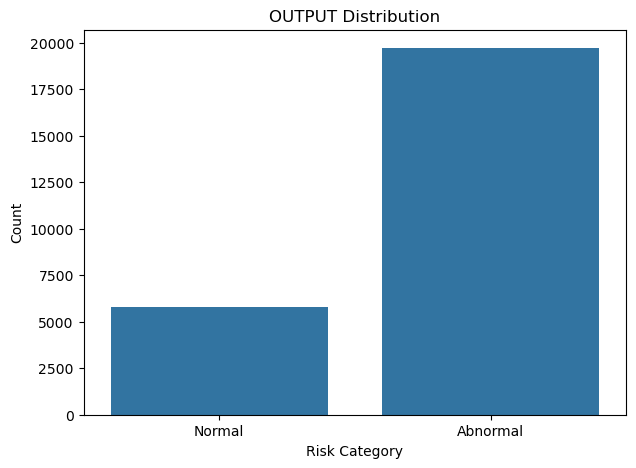

In [107]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="OUTPUT"
)

plt.title("OUTPUT Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Count")

plt.show()

In [108]:
print("🔢 Numerical Features:")

numeric_features = df.select_dtypes(
    include=np.number
).columns.tolist()

if "OUTPUT" in numeric_features:
    numeric_features.remove("OUTPUT")

print(numeric_features)

🔢 Numerical Features:
['Time (s)', ' HR (BPM)', ' RESP (BPM)', ' SpO2 (%)', 'TEMP (*C)']


In [109]:
display(df[numeric_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
Time (s),25493.0,239.981132,138.855230,-1.0,120.0,240.0,360.0,480.0
HR (BPM),25488.0,89.127943,13.220448,44.0,81.0,89.0,95.0,139.0
RESP (BPM),25346.0,17.640496,3.589381,0.0,16.0,18.0,20.0,34.0
SpO2 (%),25366.0,96.716471,3.323381,83.0,95.0,97.0,99.0,111.0
TEMP (*C),25493.0,37.590123,5.211265,21.0,34.0,38.0,41.0,49.0


## Time Distribution

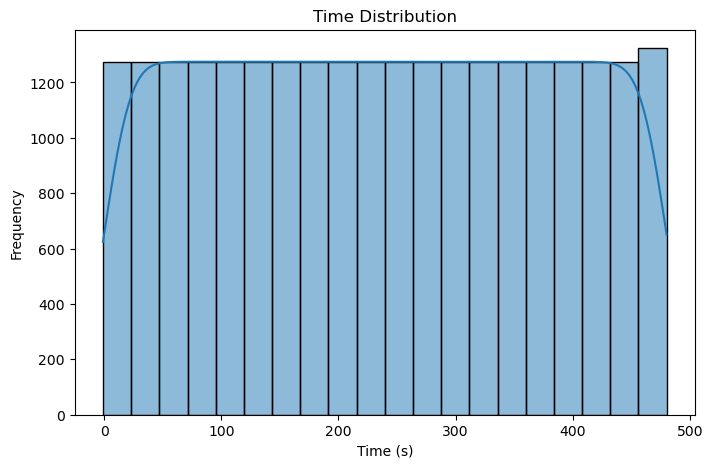

In [110]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Time (s)",
    bins=20,
    kde=True
)

plt.title("Time Distribution")
plt.xlabel("Time (s)")
plt.ylabel("Frequency")

plt.show()

## Heart Rate Distribution

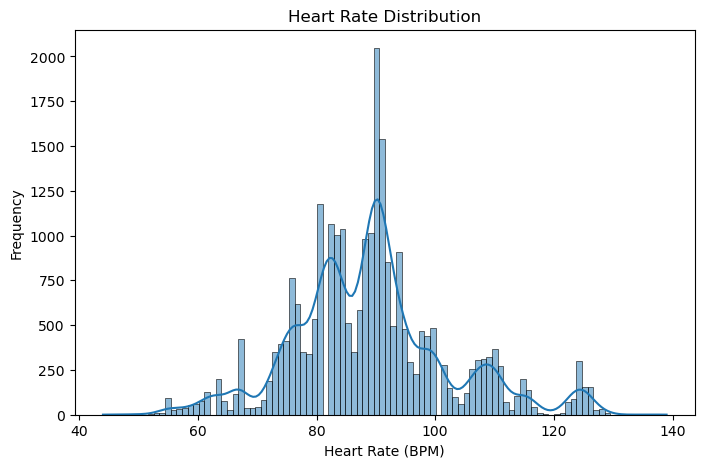

In [111]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x=" HR (BPM)",
    kde=True
)

plt.title("Heart Rate Distribution")
plt.xlabel("Heart Rate (BPM)")
plt.ylabel("Frequency")

plt.show()

## Respiratory Rate Distribution

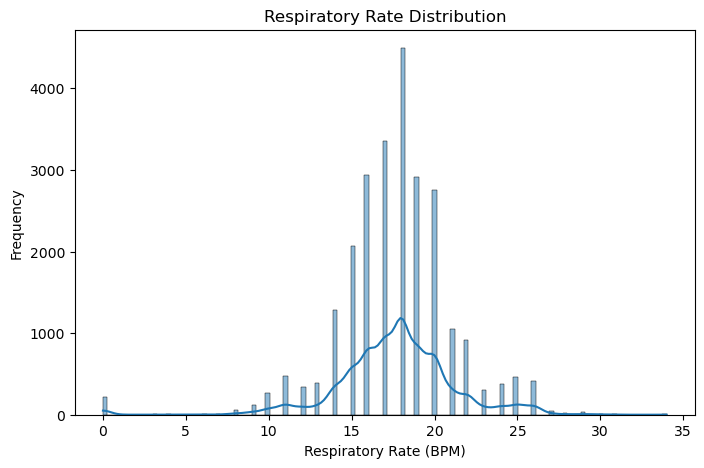

In [112]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x=" RESP (BPM)",
    kde=True
)

plt.title("Respiratory Rate Distribution")
plt.xlabel("Respiratory Rate (BPM)")
plt.ylabel("Frequency")

plt.show()

## SpO2 Distribution

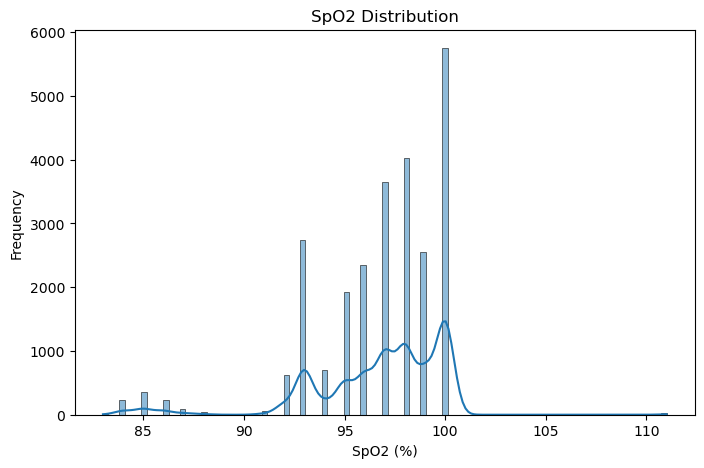

In [113]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x=" SpO2 (%)",
    kde=True
)

plt.title("SpO2 Distribution")
plt.xlabel("SpO2 (%)")
plt.ylabel("Frequency")

plt.show()

## SpO2 Boxplot

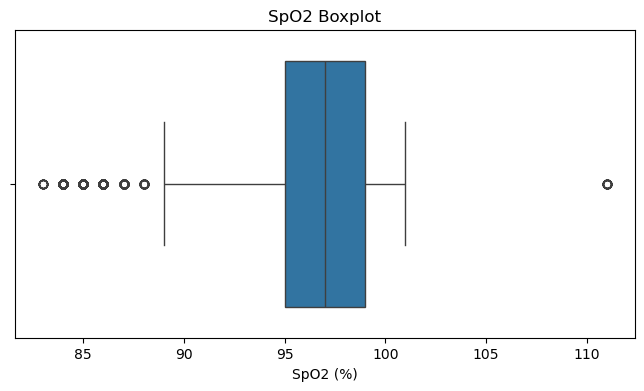

In [114]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df,
    x=" SpO2 (%)"
)

plt.title("SpO2 Boxplot")
plt.xlabel("SpO2 (%)")

plt.show()

## Temperature Distribution

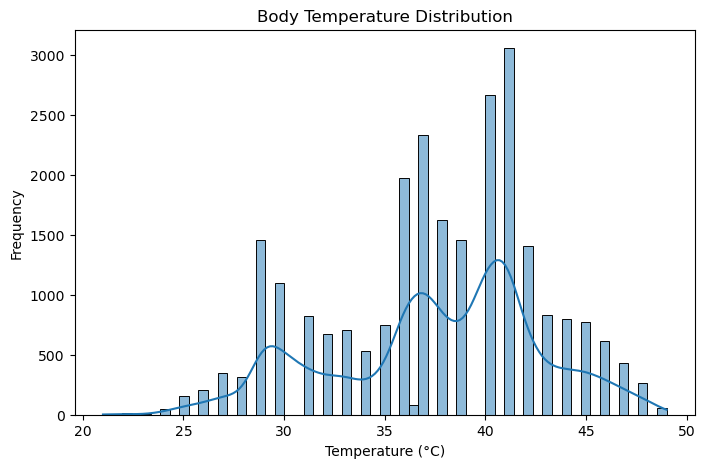

In [115]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="TEMP (*C)",
    kde=True
)

plt.title("Body Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")

plt.show()

## Heart Rate Boxplot

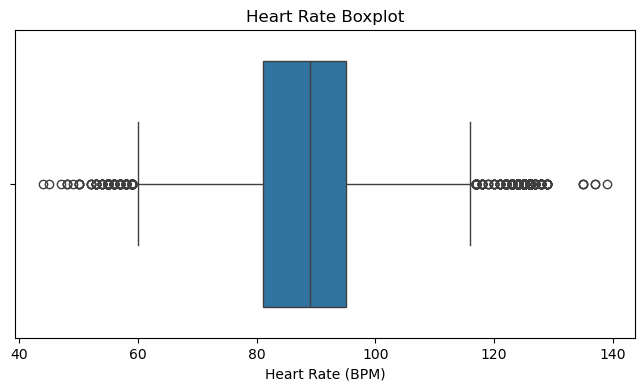

In [116]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df,
    x=" HR (BPM)"
)

plt.title("Heart Rate Boxplot")
plt.xlabel("Heart Rate (BPM)")

plt.show()

## Respiratory Rate Boxplot

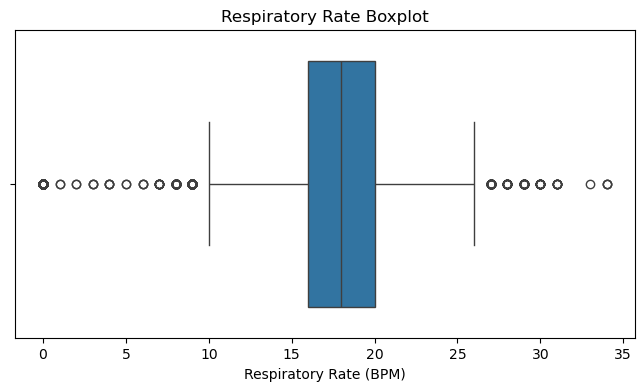

In [117]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df,
    x=" RESP (BPM)"
)

plt.title("Respiratory Rate Boxplot")
plt.xlabel("Respiratory Rate (BPM)")

plt.show()

## Temperature Boxplot

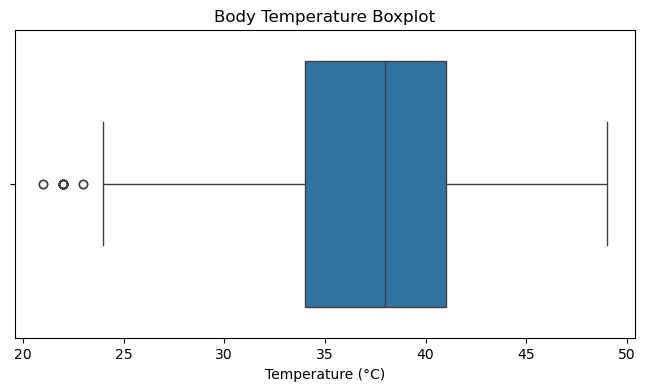

In [118]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df,
    x="TEMP (*C)"
)

plt.title("Body Temperature Boxplot")
plt.xlabel("Temperature (°C)")

plt.show()

## Heart Rate vs OUTPUT

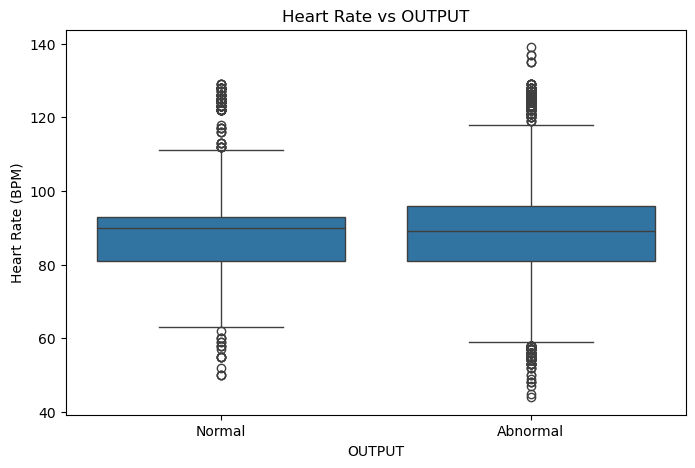

In [119]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="OUTPUT",
    y=" HR (BPM)"
)

plt.title("Heart Rate vs OUTPUT")
plt.xlabel("OUTPUT")
plt.ylabel("Heart Rate (BPM)")

plt.show()

## Respiratory Rate vs OUTPUT

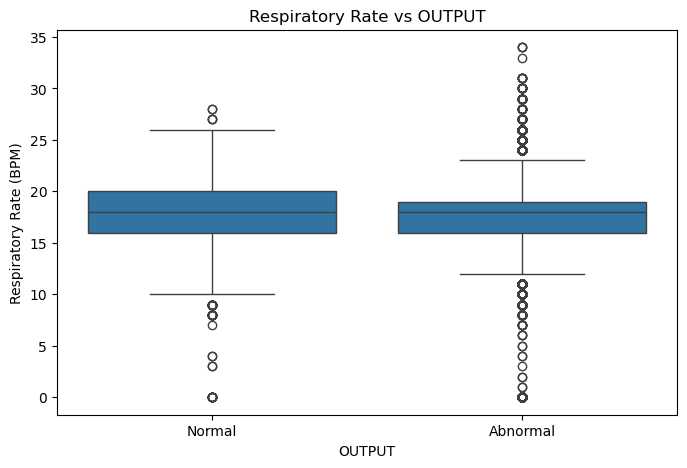

In [120]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="OUTPUT",
    y=" RESP (BPM)"
)

plt.title("Respiratory Rate vs OUTPUT")
plt.xlabel("OUTPUT")
plt.ylabel("Respiratory Rate (BPM)")

plt.show()

## SpO2 vs OUTPUT

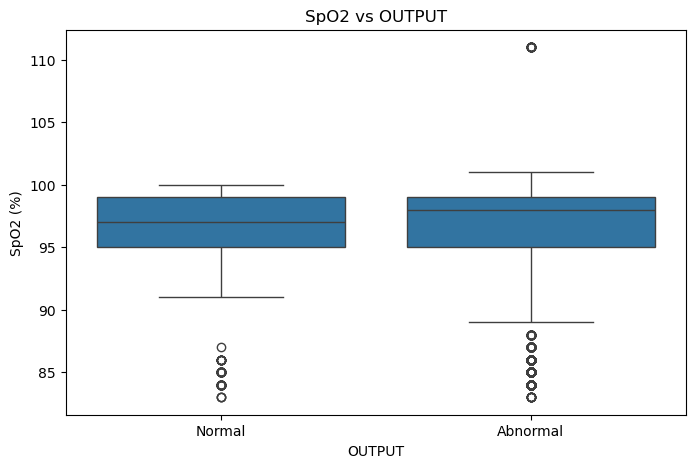

In [121]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="OUTPUT",
    y=" SpO2 (%)"
)

plt.title("SpO2 vs OUTPUT")
plt.xlabel("OUTPUT")
plt.ylabel("SpO2 (%)")

plt.show()

## Temperature vs OUTPUT

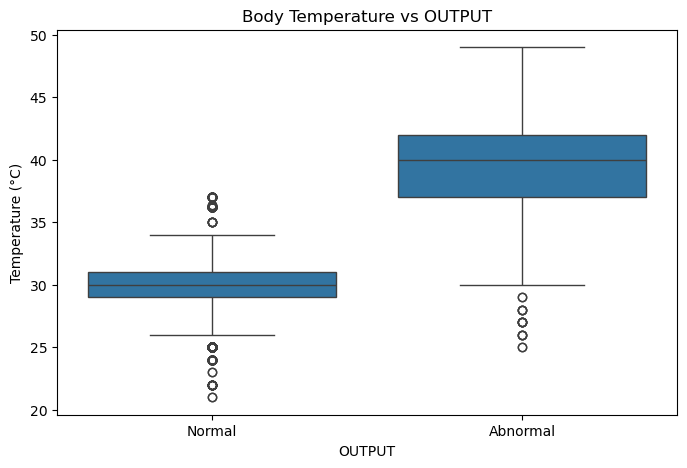

In [122]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="OUTPUT",
    y="TEMP (*C)"
)

plt.title("Body Temperature vs OUTPUT")
plt.xlabel("OUTPUT")
plt.ylabel("Temperature (°C)")

plt.show()

## Time vs OUTPUT

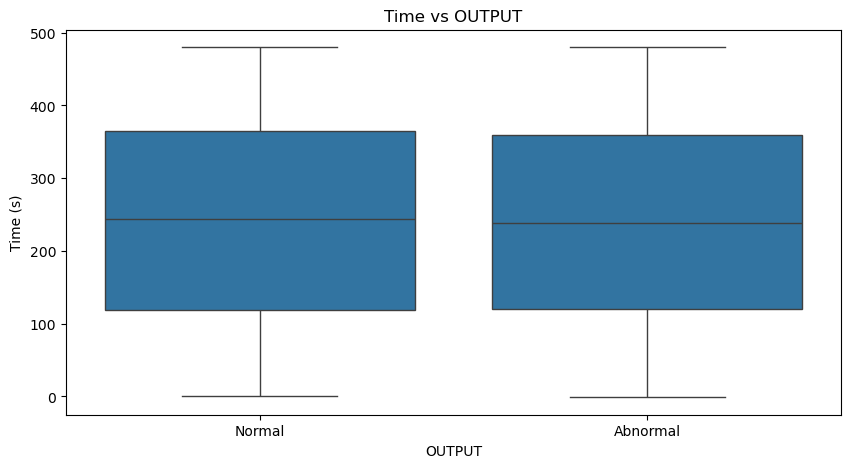

In [123]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="OUTPUT",
    y="Time (s)"
)

plt.title("Time vs OUTPUT")
plt.xlabel("OUTPUT")
plt.ylabel("Time (s)")

plt.show()

## Heart Rate Over Time

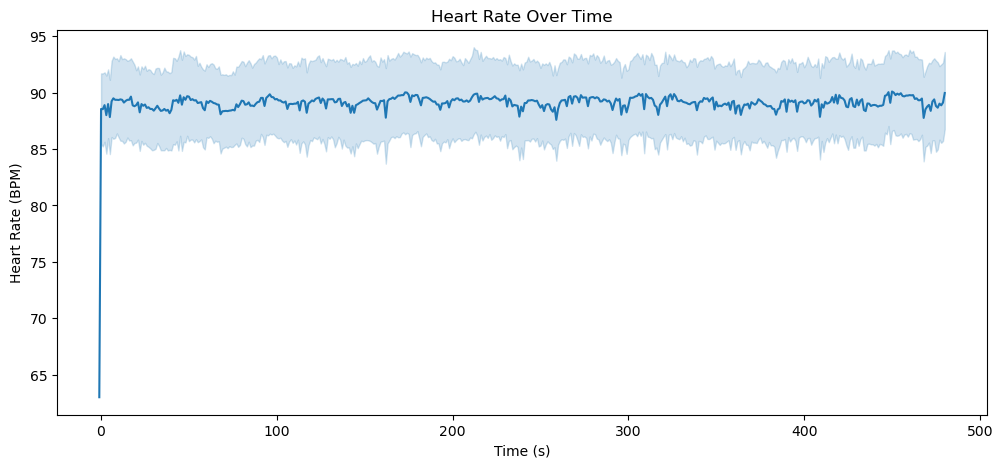

In [124]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=df,
    x="Time (s)",
    y=" HR (BPM)"
)

plt.title("Heart Rate Over Time")
plt.xlabel("Time (s)")
plt.ylabel("Heart Rate (BPM)")

plt.show()

## Respiratory Rate Over Time

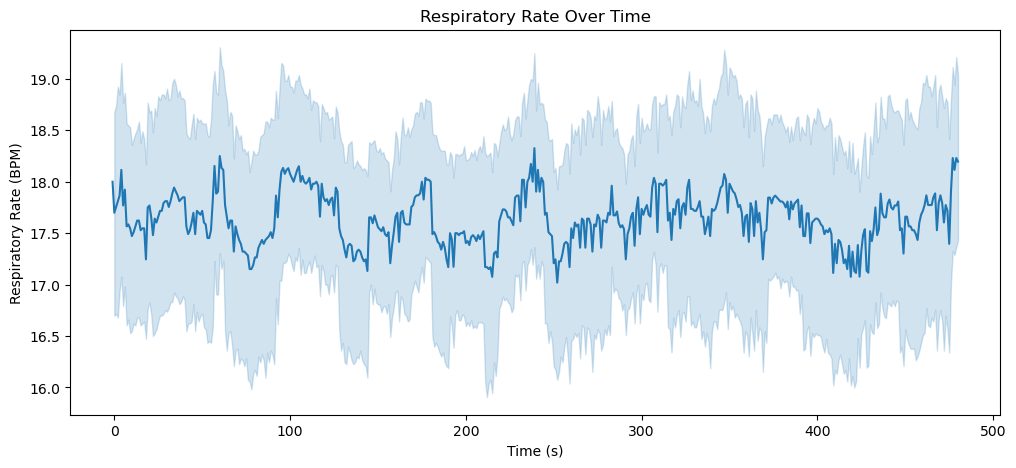

In [125]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=df,
    x="Time (s)",
    y=" RESP (BPM)"
)

plt.title("Respiratory Rate Over Time")
plt.xlabel("Time (s)")
plt.ylabel("Respiratory Rate (BPM)")

plt.show()

## SpO2 Over Time

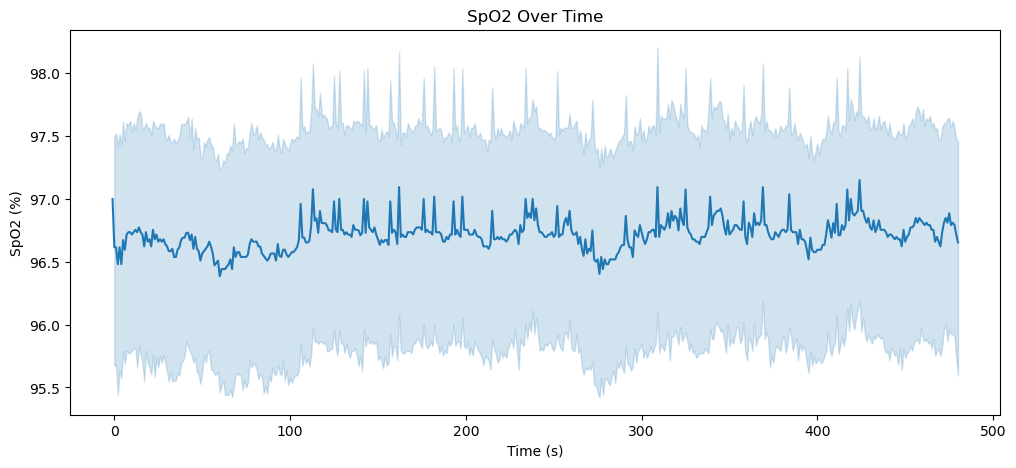

In [126]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=df,
    x="Time (s)",
    y=" SpO2 (%)"
)

plt.title("SpO2 Over Time")
plt.xlabel("Time (s)")
plt.ylabel("SpO2 (%)")

plt.show()

## Temperature Over Time

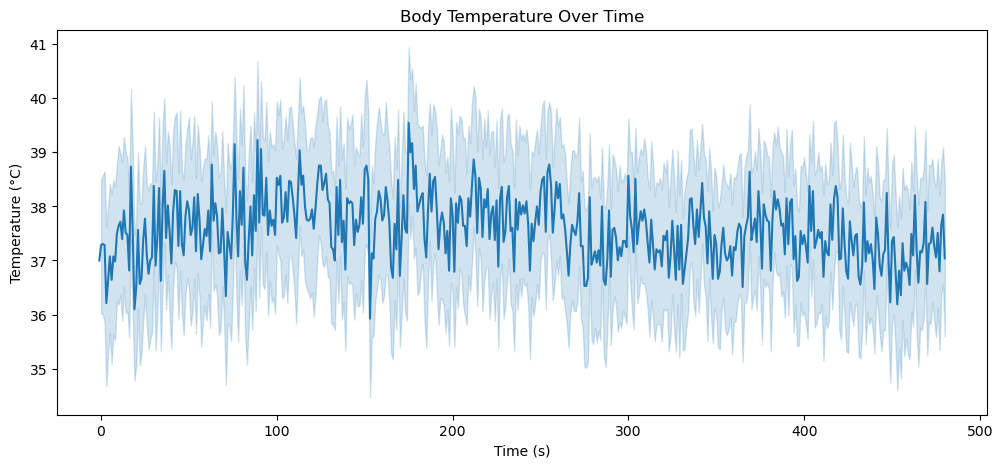

In [127]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=df,
    x="Time (s)",
    y="TEMP (*C)"
)

plt.title("Body Temperature Over Time")
plt.xlabel("Time (s)")
plt.ylabel("Temperature (°C)")

plt.show()

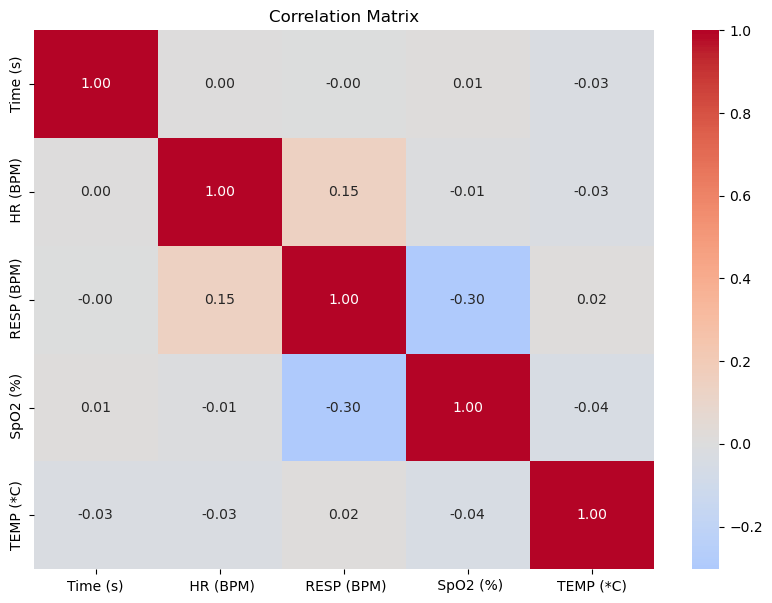

In [128]:
correlation = df[
    [
        "Time (s)",
        " HR (BPM)",
        " RESP (BPM)",
        " SpO2 (%)",
        "TEMP (*C)"
    ]
].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

In [129]:
print("HR = 0:", (df[" HR (BPM)"] == 0).sum())
print("RESP = 0:", (df[" RESP (BPM)"] == 0).sum())

HR = 0: 0
RESP = 0: 219


In [130]:
print("HR <= 0:", (df[" HR (BPM)"] <= 0).sum())
print("RESP <= 0:", (df[" RESP (BPM)"] <= 0).sum())
print("Temperature <= 0:", (df["TEMP (*C)"] <= 0).sum())
print("SpO2 < 0:", (df[" SpO2 (%)"] < 0).sum())
print("SpO2 > 100:", (df[" SpO2 (%)"] > 100).sum())

HR <= 0: 0
RESP <= 0: 219
Temperature <= 0: 0
SpO2 < 0: 0
SpO2 > 100: 28


# <div style="color:#fff;display:fill;border-radius:10px;background-color:#000080;text-align:center;letter-spacing:0.1px;overflow:hidden;padding:20px;color:white;overflow:hidden;margin:0;mfont-size:100%">Data Cleaning </div>

In [131]:
print("Before removing duplicates:", df.shape)
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

# Handle physiologically invalid values before creating the modeling dataset
df.loc[df[" RESP (BPM)"] <= 0, " RESP (BPM)"] = np.nan
df.loc[
    (df[" SpO2 (%)"] < 0) | (df[" SpO2 (%)"] > 100),
    " SpO2 (%)"
] = np.nan

Before removing duplicates: (25493, 6)
After removing duplicates: (25474, 6)


In [132]:
print("Remaining duplicates:", df.duplicated().sum())

Remaining duplicates: 0


### 🎯 Removing the Time Feature
### The Time (s) column represents the measurement time index and shows very weak relationships with the other features and the target distribution.
### Therefore, it will not be used as a predictive feature in the machine learning models.

In [133]:
model_df = df.drop(columns=["Time (s)"]).copy()

# Remove repeated feature/target combinations after excluding Time
repeated_rows = model_df.duplicated().sum()
print("Repeated feature/target rows before removal:", repeated_rows)
model_df = model_df.drop_duplicates().copy()
print("Repeated feature/target rows after removal:", model_df.duplicated().sum())

model_df.head()

Repeated feature/target rows before removal: 17286
Repeated feature/target rows after removal: 0


,HR (BPM),RESP (BPM),SpO2 (%),TEMP (*C),OUTPUT
0,94.0,21.0,97.0,36.2,Normal
1,94.0,25.0,97.0,36.2,Normal
2,101.0,25.0,93.0,38.0,Abnormal
3,55.0,11.0,100.0,35.0,Abnormal
4,93.0,26.0,95.0,37.0,Normal


In [134]:
missing = model_df.isnull().sum()
print(missing)

 HR (BPM)       4
 RESP (BPM)    27
 SpO2 (%)      73
TEMP (*C)       0
OUTPUT          0
dtype: int64


In [135]:
print("Invalid SpO2 values:")
print(model_df[model_df[" SpO2 (%)"] > 100][" SpO2 (%)"].value_counts())

Invalid SpO2 values:
Series([], Name: count, dtype: int64)


In [136]:
print("SpO2 below 0:")
print((model_df[" SpO2 (%)"] < 0).sum())

print("SpO2 above 100:")
print((model_df[" SpO2 (%)"] > 100).sum())

SpO2 below 0:
0
SpO2 above 100:
0


In [137]:
model_df.loc[
    (model_df[" SpO2 (%)"] < 0) |
    (model_df[" SpO2 (%)"] > 100),
    " SpO2 (%)"
] = np.nan

In [138]:
print("SpO2 below 0:")
print((model_df[" SpO2 (%)"] < 0).sum())

print("SpO2 above 100:")
print((model_df[" SpO2 (%)"] > 100).sum())

SpO2 below 0:
0
SpO2 above 100:
0


In [139]:
print(
    model_df[" RESP (BPM)"].describe()
)

count    8161.000000
mean       17.536331
std         3.304955
min         1.000000
25%        16.000000
50%        17.000000
75%        19.000000
max        34.000000
Name:  RESP (BPM), dtype: float64


In [140]:
print(
    "RESP = 0:",
    (model_df[" RESP (BPM)"] == 0).sum()
)

RESP = 0: 0


In [141]:
print(
    model_df[" HR (BPM)"].describe()
)

count    8184.000000
mean       89.641251
std        13.105475
min        44.000000
25%        81.000000
50%        89.000000
75%        96.000000
max       139.000000
Name:  HR (BPM), dtype: float64


In [142]:
print(
    model_df[" HR (BPM)"].sort_values().head(10)
)

print(
    model_df[" HR (BPM)"].sort_values().tail(10)
)

21298    44.0
21243    45.0
21297    47.0
21589    48.0
21242    48.0
21414    48.0
21208    49.0
21413    50.0
19276    50.0
19277    50.0
Name:  HR (BPM), dtype: float64
10090    129.0
11756    135.0
11760    135.0
11758    137.0
11759    137.0
11755    139.0
12713      NaN
12714      NaN
12716      NaN
16668      NaN
Name:  HR (BPM), dtype: float64


In [143]:
print("RESP <= 0 after cleaning:", (model_df[" RESP (BPM)"] <= 0).sum())


RESP <= 0 after cleaning: 0


In [144]:
print("RESP <= 0:", (model_df[" RESP (BPM)"] <= 0).sum())


RESP <= 0: 0


In [145]:
print("Shape:", model_df.shape)

print("\nMissing Values:")
print(model_df.isnull().sum())

print("\nDuplicates:")
print(model_df.duplicated().sum())

Shape: (8188, 5)

Missing Values:
 HR (BPM)       4
 RESP (BPM)    27
 SpO2 (%)      73
TEMP (*C)       0
OUTPUT          0
dtype: int64

Duplicates:
0


In [146]:
print(model_df.columns.tolist())

[' HR (BPM)', ' RESP (BPM)', ' SpO2 (%)', 'TEMP (*C)', 'OUTPUT']


## 🎯Final Data Cleaning Decisions

### - Exact duplicate rows were removed.
### - Physiologically invalid Respiratory Rate and SpO2 values were treated as missing values.
### - Repeated feature/target combinations were removed after excluding the Time (s) feature to avoid overlap between training and test samples.
### - The Time (s) column will not be used as a model feature.
### - Missing values will be handled by median imputation inside the preprocessing pipeline.


# <div style="color:#fff;display:fill;border-radius:10px;background-color:#000080;text-align:center;letter-spacing:0.1px;overflow:hidden;padding:20px;color:white;overflow:hidden;margin:0;mfont-size:100%">Machine Learning</div>

In [147]:
display(model_df.head())

,HR (BPM),RESP (BPM),SpO2 (%),TEMP (*C),OUTPUT
0,94.0,21.0,97.0,36.2,Normal
1,94.0,25.0,97.0,36.2,Normal
2,101.0,25.0,93.0,38.0,Abnormal
3,55.0,11.0,100.0,35.0,Abnormal
4,93.0,26.0,95.0,37.0,Normal


## 🎯 Target Encoding
###  The target variable OUTPUT will be encoded as:
###  - Normal = 0
###  - Abnormal = 1

In [148]:
model_df["OUTPUT"] = model_df["OUTPUT"].map({
    "Normal": 0,
    "Abnormal": 1
})

print(model_df["OUTPUT"].value_counts())

OUTPUT
1    6452
0    1736
Name: count, dtype: int64


In [149]:
X = model_df.drop(columns=["OUTPUT"])
y = model_df["OUTPUT"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
[' HR (BPM)', ' RESP (BPM)', ' SpO2 (%)', 'TEMP (*C)']

Target:
OUTPUT


### Train-Test Split

The cleaned dataset is split into stratified training and test sets. Repeated feature/target combinations were removed before splitting to reduce train-test overlap.


In [150]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nTraining distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True))

X_train: (6550, 4)
X_test : (1638, 4)

Training distribution:
OUTPUT
1    0.787939
0    0.212061
Name: proportion, dtype: float64

Testing distribution:
OUTPUT
1    0.788156
0    0.211844
Name: proportion, dtype: float64


In [151]:
preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [152]:
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

print("Class distribution:")
print(y_train.value_counts())

print("\nSample weights:")
print(pd.Series(sample_weights).value_counts())

Class distribution:
OUTPUT
1    5161
0    1389
Name: count, dtype: int64

Sample weights:
0.634567    5161
2.357811    1389
Name: count, dtype: int64


In [153]:
def evaluate_model(model, X_test, y_test, model_name):
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    
    precision = precision_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )
    
    recall = recall_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )
    
    f1 = f1_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )
    
    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )
    
    print("=" * 60)
    print(model_name)
    print("=" * 60)
    
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")
    
    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Normal", "Abnormal"],
            zero_division=0
        )
    )
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    }

## 🤖 Logistic Regression
### Logistic Regression is used as the baseline classification model.

In [154]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

logistic_model.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('imputer', ...), ('scaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None


In [155]:
logistic_result = evaluate_model(
    logistic_model,
    X_test,
    y_test,
    "Logistic Regression"
)

Logistic Regression
Accuracy : 0.9609
Precision: 0.9239
Recall   : 0.9710
F1-Score : 0.9447
ROC-AUC  : 0.9913

Classification Report:
              precision    recall  f1-score   support

      Normal       0.85      0.99      0.91       347
    Abnormal       1.00      0.95      0.97      1291

    accuracy                           0.96      1638
   macro avg       0.92      0.97      0.94      1638
weighted avg       0.97      0.96      0.96      1638

Confusion Matrix:
[[ 343    4]
 [  60 1231]]


## 🤖 Random Forest

### Random Forest is used as a tree-based classification model for comparison with the Logistic Regression baseline.

In [156]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

rf_model.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('imputer', ...), ('scaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None


In [157]:
rf_result = evaluate_model(
    rf_model,
    X_test,
    y_test,
    "Random Forest"
)

Random Forest
Accuracy : 0.9860
Precision: 0.9748
Recall   : 0.9837
F1-Score : 0.9792
ROC-AUC  : 0.9991

Classification Report:
              precision    recall  f1-score   support

      Normal       0.96      0.98      0.97       347
    Abnormal       0.99      0.99      0.99      1291

    accuracy                           0.99      1638
   macro avg       0.97      0.98      0.98      1638
weighted avg       0.99      0.99      0.99      1638

Confusion Matrix:
[[ 340    7]
 [  16 1275]]


## 🤖 XGBoost
### XGBoost is used as an additional gradient-boosting classification model.

In [158]:
from xgboost import XGBClassifier

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    ))
])

xgb_model.fit(
    X_train,
    y_train,
    model__sample_weight=sample_weights
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('imputer', ...), ('scaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None


In [159]:
xgb_result = evaluate_model(
    xgb_model,
    X_test,
    y_test,
    "XGBoost"
)

XGBoost
Accuracy : 0.9841
Precision: 0.9683
Recall   : 0.9857
F1-Score : 0.9767
ROC-AUC  : 0.9991

Classification Report:
              precision    recall  f1-score   support

      Normal       0.94      0.99      0.96       347
    Abnormal       1.00      0.98      0.99      1291

    accuracy                           0.98      1638
   macro avg       0.97      0.99      0.98      1638
weighted avg       0.98      0.98      0.98      1638

Confusion Matrix:
[[ 343    4]
 [  22 1269]]


## 🎯 Model Comparison
### The three classification models are compared using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

In [160]:
results = pd.DataFrame([
    logistic_result,
    rf_result,
    xgb_result
])

display(
    results.sort_values(
        by="F1-Score",
        ascending=False
    ).reset_index(drop=True)
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.985958,0.974798,0.983717,0.979172,0.999143
1,XGBoost,0.984127,0.968292,0.985716,0.976671,0.999076
2,Logistic Regression,0.960928,0.923939,0.970999,0.944665,0.991294


In [161]:
results_sorted = results.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

display(results_sorted)

best_model_name = results_sorted.loc[0, "Model"]

print("Selected Model:", best_model_name)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.985958,0.974798,0.983717,0.979172,0.999143
1,XGBoost,0.984127,0.968292,0.985716,0.976671,0.999076
2,Logistic Regression,0.960928,0.923939,0.970999,0.944665,0.991294


Selected Model: Random Forest


In [162]:
models = {
    "Logistic Regression": logistic_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

best_model = models[best_model_name]

print("Best model:", best_model_name)

Best model: Random Forest


In [163]:
y_pred_best = best_model.predict(X_test)

print(
    classification_report(
        y_test,
        y_pred_best,
        target_names=["Normal", "Abnormal"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      Normal       0.96      0.98      0.97       347
    Abnormal       0.99      0.99      0.99      1291

    accuracy                           0.99      1638
   macro avg       0.97      0.98      0.98      1638
weighted avg       0.99      0.99      0.99      1638



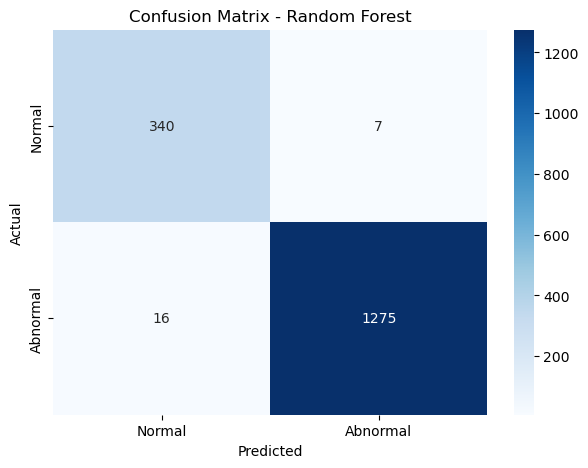

In [164]:
cm = confusion_matrix(
    y_test,
    y_pred_best
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Abnormal"],
    yticklabels=["Normal", "Abnormal"]
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Saving the Best Model

In [165]:
import joblib

joblib.dump(
    best_model,
    "best_vital_signs_model.joblib"
)

print("Best model saved successfully!")

Best model saved successfully!


## Feature Importance
### Feature importance is used to understand which vital signs contribute most to the model's predictions.

In [166]:
feature_names = X.columns

model = best_model.named_steps["model"]

if hasattr(model, "feature_importances_"):
    importance = model.feature_importances_

else:
    importance = abs(model.coef_[0])

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values("Importance", ascending=False)

print(feature_importance)

       Feature  Importance
3    TEMP (*C)    0.921972
0     HR (BPM)    0.036565
1   RESP (BPM)    0.021150
2     SpO2 (%)    0.020313


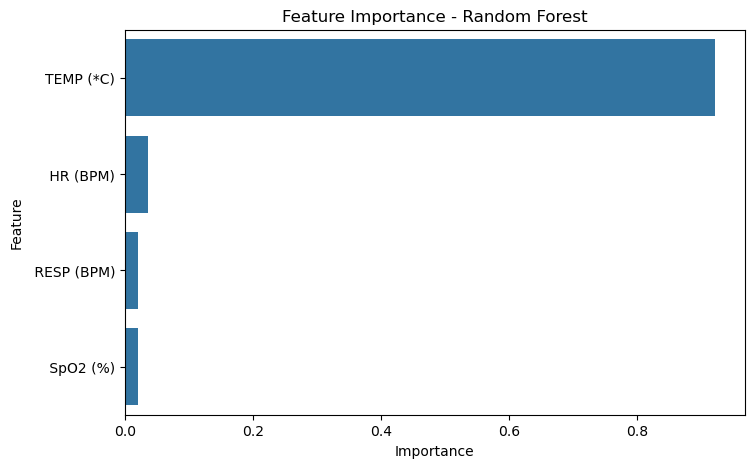

In [167]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title(f"Feature Importance - {best_model_name}")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [168]:
print(
    df.groupby("OUTPUT")[[
        " HR (BPM)",
        " RESP (BPM)",
        " SpO2 (%)",
        "TEMP (*C)"
    ]].mean()
)

           HR (BPM)   RESP (BPM)   SpO2 (%)  TEMP (*C)
OUTPUT                                                
Abnormal  89.351122    17.720184  96.648356  39.829120
Normal    88.356710    18.023628  96.880721  29.972299


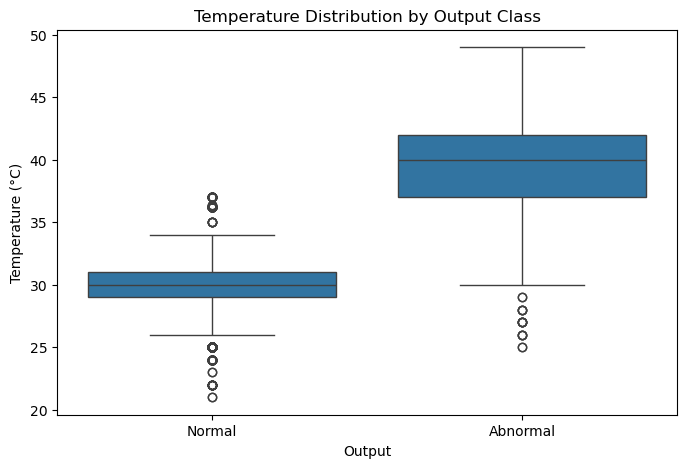

In [169]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="OUTPUT",
    y="TEMP (*C)"
)

plt.title("Temperature Distribution by Output Class")
plt.xlabel("Output")
plt.ylabel("Temperature (°C)")

plt.show()

In [170]:
!pip install shap

In [171]:
import shap

model = best_model.named_steps["model"]
preprocessor = best_model.named_steps["preprocessor"]

X_test_processed = preprocessor.transform(X_test)

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test_processed)

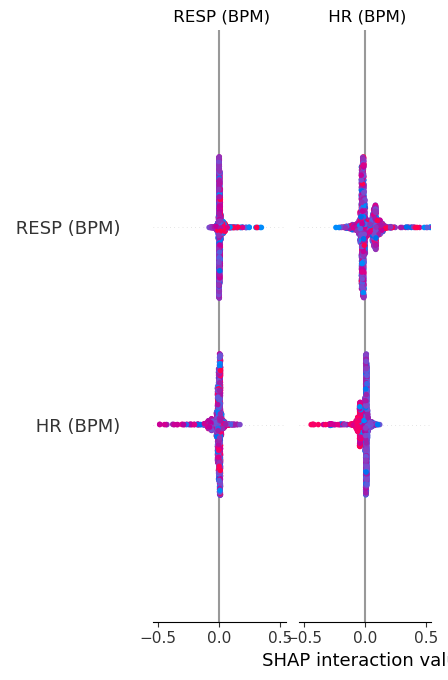

In [172]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=X.columns
)

## 🎯SHAP Interaction Analysis
### SHAP interaction values show how pairs of features jointly contribute to the model prediction.
### The plot shows the interaction between Heart Rate (HR) and Respiratory Rate (RESP). Values close to zero indicate a weak interaction, while larger absolute values indicate a stronger interaction effect.
### This analysis provides additional insight into how the model uses relationships between vital-sign features when making predictions.